# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [4]:
%pip install yellowbrick


   ---------------------------------------- 0.0/282.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/282.6 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/282.6 kB 330.3 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/282.6 kB 491.5 kB/s eta 0:00:01
   ---------------------------- ----------- 204.8/282.6 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 282.6/282.6 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [3]:
# loading data into a pandas dataframe
data = pd.read_csv("C:/Users/adars/Downloads/Customer_Personality_Segmentation.csv", sep="\t")

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [5]:
data.dtypes


ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

##### **Observations:**   we see that most of the columns have integer values that will be easy to work with. Income is a float (has decimal values). Several columns are indicated as object which if we display the first couple rows of data we see are strings.


#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [7]:
avg_income = data["Income"].mean()

print(avg_income)

52247.25135379061


##### **Observations:** Average household income comes out to 52,247.25 or roughly 52k

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [9]:
data.isnull()

print(data.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


##### **Observations:** We can see that only income has missing values (24). To make sure we don't skew the data when handling these missing values we will fill with the mean (52247.25)

In [11]:
data.fillna(52247.25, inplace = True)
print(data.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


#### **Question 4**: Are there any duplicates in the data?

In [13]:
print(data.duplicated().sum())

0


##### **Observations:** By doing a quick initial check for the total number of duplicated rows, we see that there are 0. We don't have to worry about duplicates in individual columns as that is significant to the data.

## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

<Axes: ylabel='Income'>

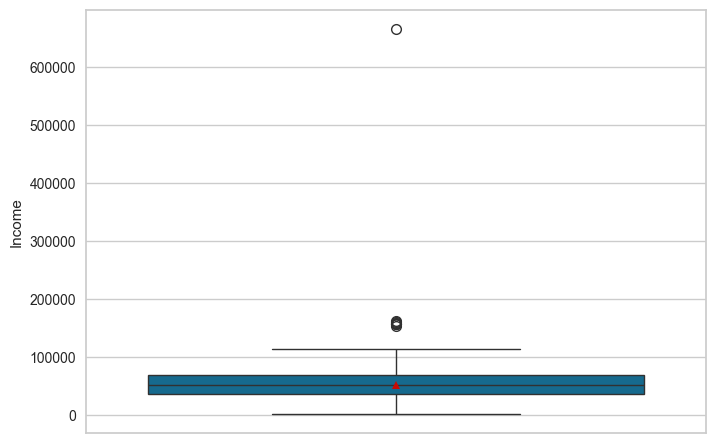

In [54]:
sns.boxplot(data["Income"], showmeans = True)



<Axes: xlabel='Year_Birth', ylabel='Count'>

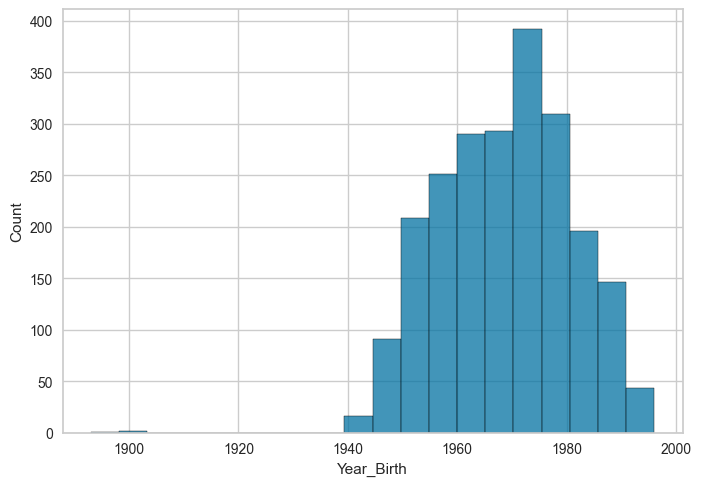

In [56]:
sns.histplot(data = data, x = "Year_Birth", bins = 20)

 ## Observations: Our data is skewed towards the lower end of the income distribution, and slightly towards the older age demographic (born between 1960 - 1980)

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationships between the variables.

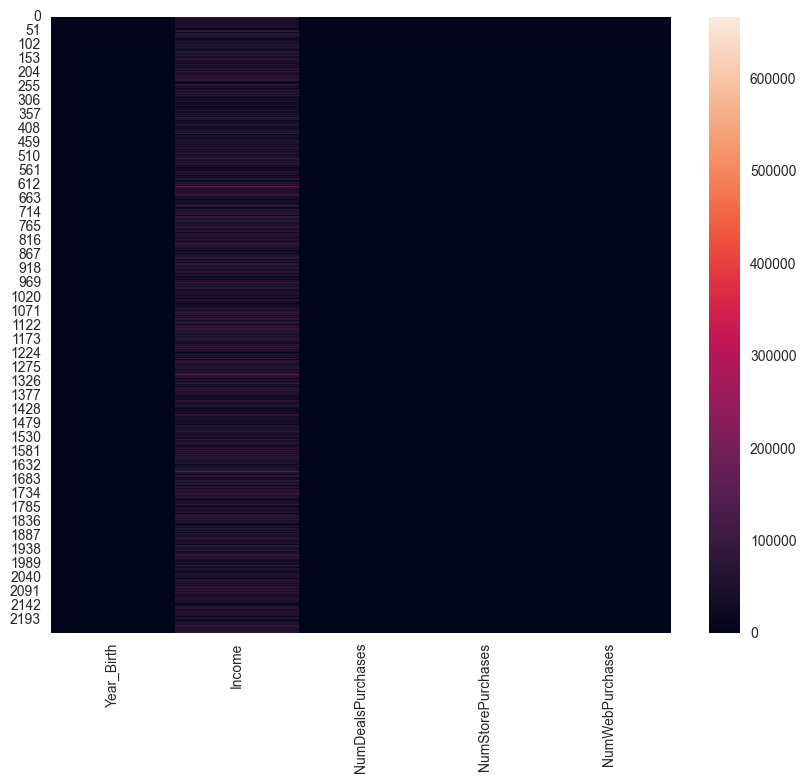

In [76]:
data_subset = data[['Year_Birth', 'Income', 'NumDealsPurchases', 'NumStorePurchases', 'NumWebPurchases']]


plt.figure(figsize=(10, 8))
sns.heatmap(data_subset)
plt.show()


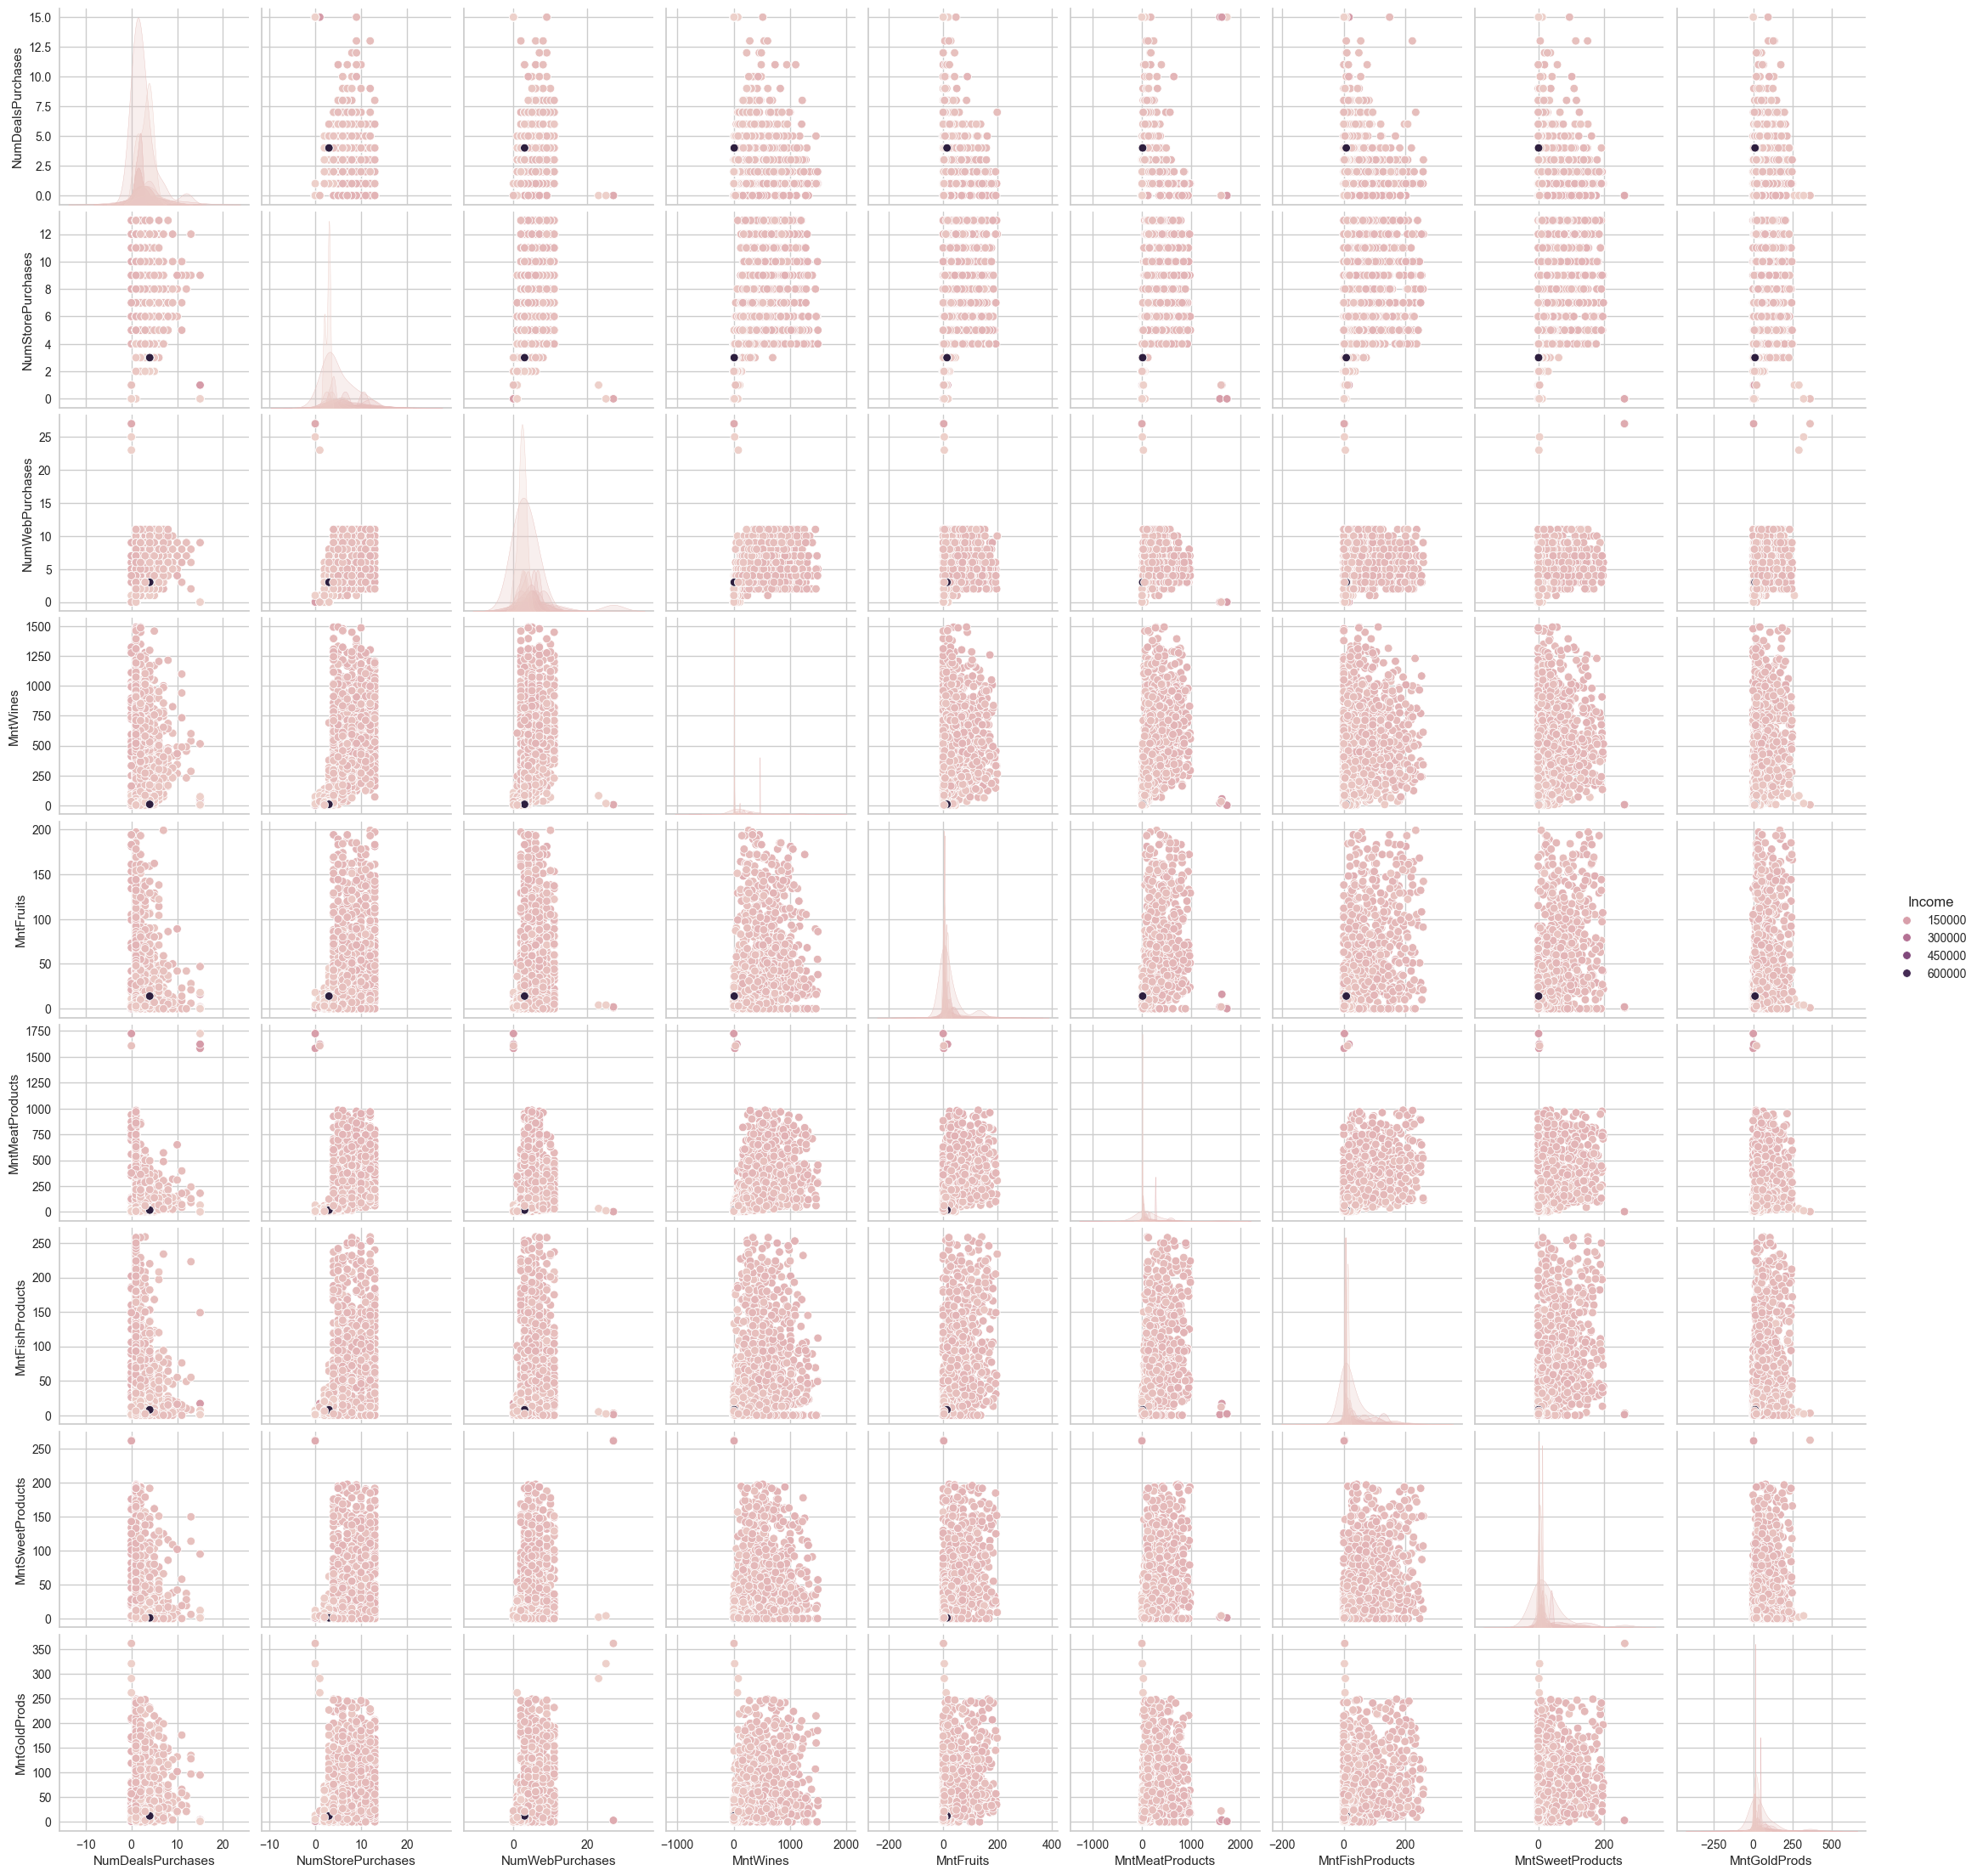

In [79]:
pairplot_subset = data[['Income', 'NumDealsPurchases', 'NumStorePurchases', 'NumWebPurchases', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']]

sns.pairplot(pairplot_subset, hue='Income')
plt.show()

##### **Observations:**  Both number of deals purchased, and number of store purchases seem to show strong correlations with income, lower income (lighter hue) accounts for way more store purchases and deals purchased. Age doesn't seem to have any strong correlation with either deals purchased, web purchases, or store purchases

## **K-means Clustering**

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

In [15]:
kmeans_subset = data[['Income', 'NumDealsPurchases', 'NumStorePurchases', 'NumWebPurchases', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 
                      'MntGoldProds', 'Kidhome', 'Teenhome', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']]


scaler = StandardScaler() 
useable_data = scaler.fit_transform(kmeans_subset)

df = pd.DataFrame(useable_data)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
0,0.235327,0.349414,-0.550785,1.409304,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,-0.825218,-0.929894,0.693904,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,2.388846
1,-0.235826,-0.168236,-1.166125,-1.110409,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,1.032559,0.906934,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612
2,0.773633,-0.685887,1.295237,1.409304,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,-0.825218,-0.929894,-0.542647,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612
3,-1.022732,-0.168236,-0.550785,-0.750450,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,1.032559,-0.929894,0.281720,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612
4,0.241519,1.384715,0.064556,0.329427,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,1.032559,-0.929894,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.0,0.0,-0.418612


In [89]:
#troubleshooting model not working error


In [17]:

wcss = []

for k in range(1,15):
    kmeans = KMeans(n_clusters= k, random_state=1) 
    kmeans.fit(useable_data)
    wcss.append(kmeans.inertia_)




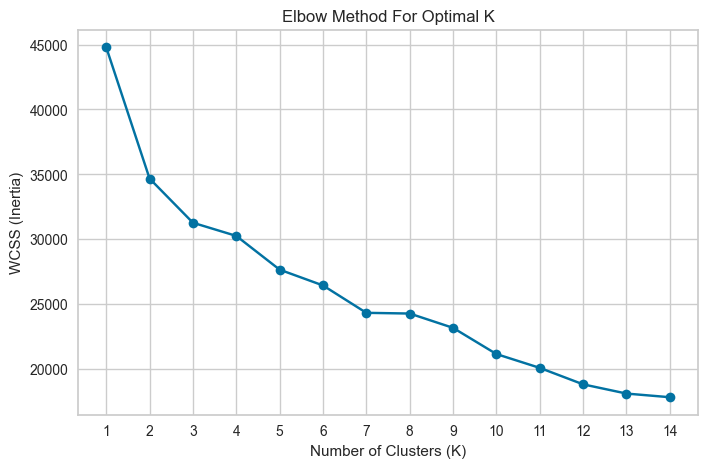

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 15), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method For Optimal K')
plt.xticks(range(1, 15))
plt.grid(True)
plt.show()

##### **Observations:** Income is very large values relative to age, and this could throw the clustering off, so first we have to scale the data. After plotting the elbow curve we don't really see nice ideal value for K but the elbow seems to be between 5 and 7. A silhoutte score may help clarify.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

In [40]:
# Write your code here
for k in range(4,9):
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(useable_data)
    score = silhouette_score(useable_data, labels)
    print(score)

0.10453373112385247
0.22119232017768534
0.21107498274316075
0.2211338144160072
0.129592204177293


##### **Observations:** Unfortunately we see in the silhouette score that 5 and 7 have roughly equal scores, and the value is not very close to 1 indicating there is probably a lot of overlap in the data. Although I believe both 5 and 7 to be good K values, based on the elbow score showing a sharper bend at 7 I will go with k = 7 clusters.

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [43]:
import time

start = time.time()

kmeans = KMeans(n_clusters=7, random_state=1)
kmeans.fit(useable_data)

end = time.time()

print("Training time", end - start, "seconds")

Training time 0.02279210090637207 seconds


##### **Observations:** it took 0.228 seconds to fit the data

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

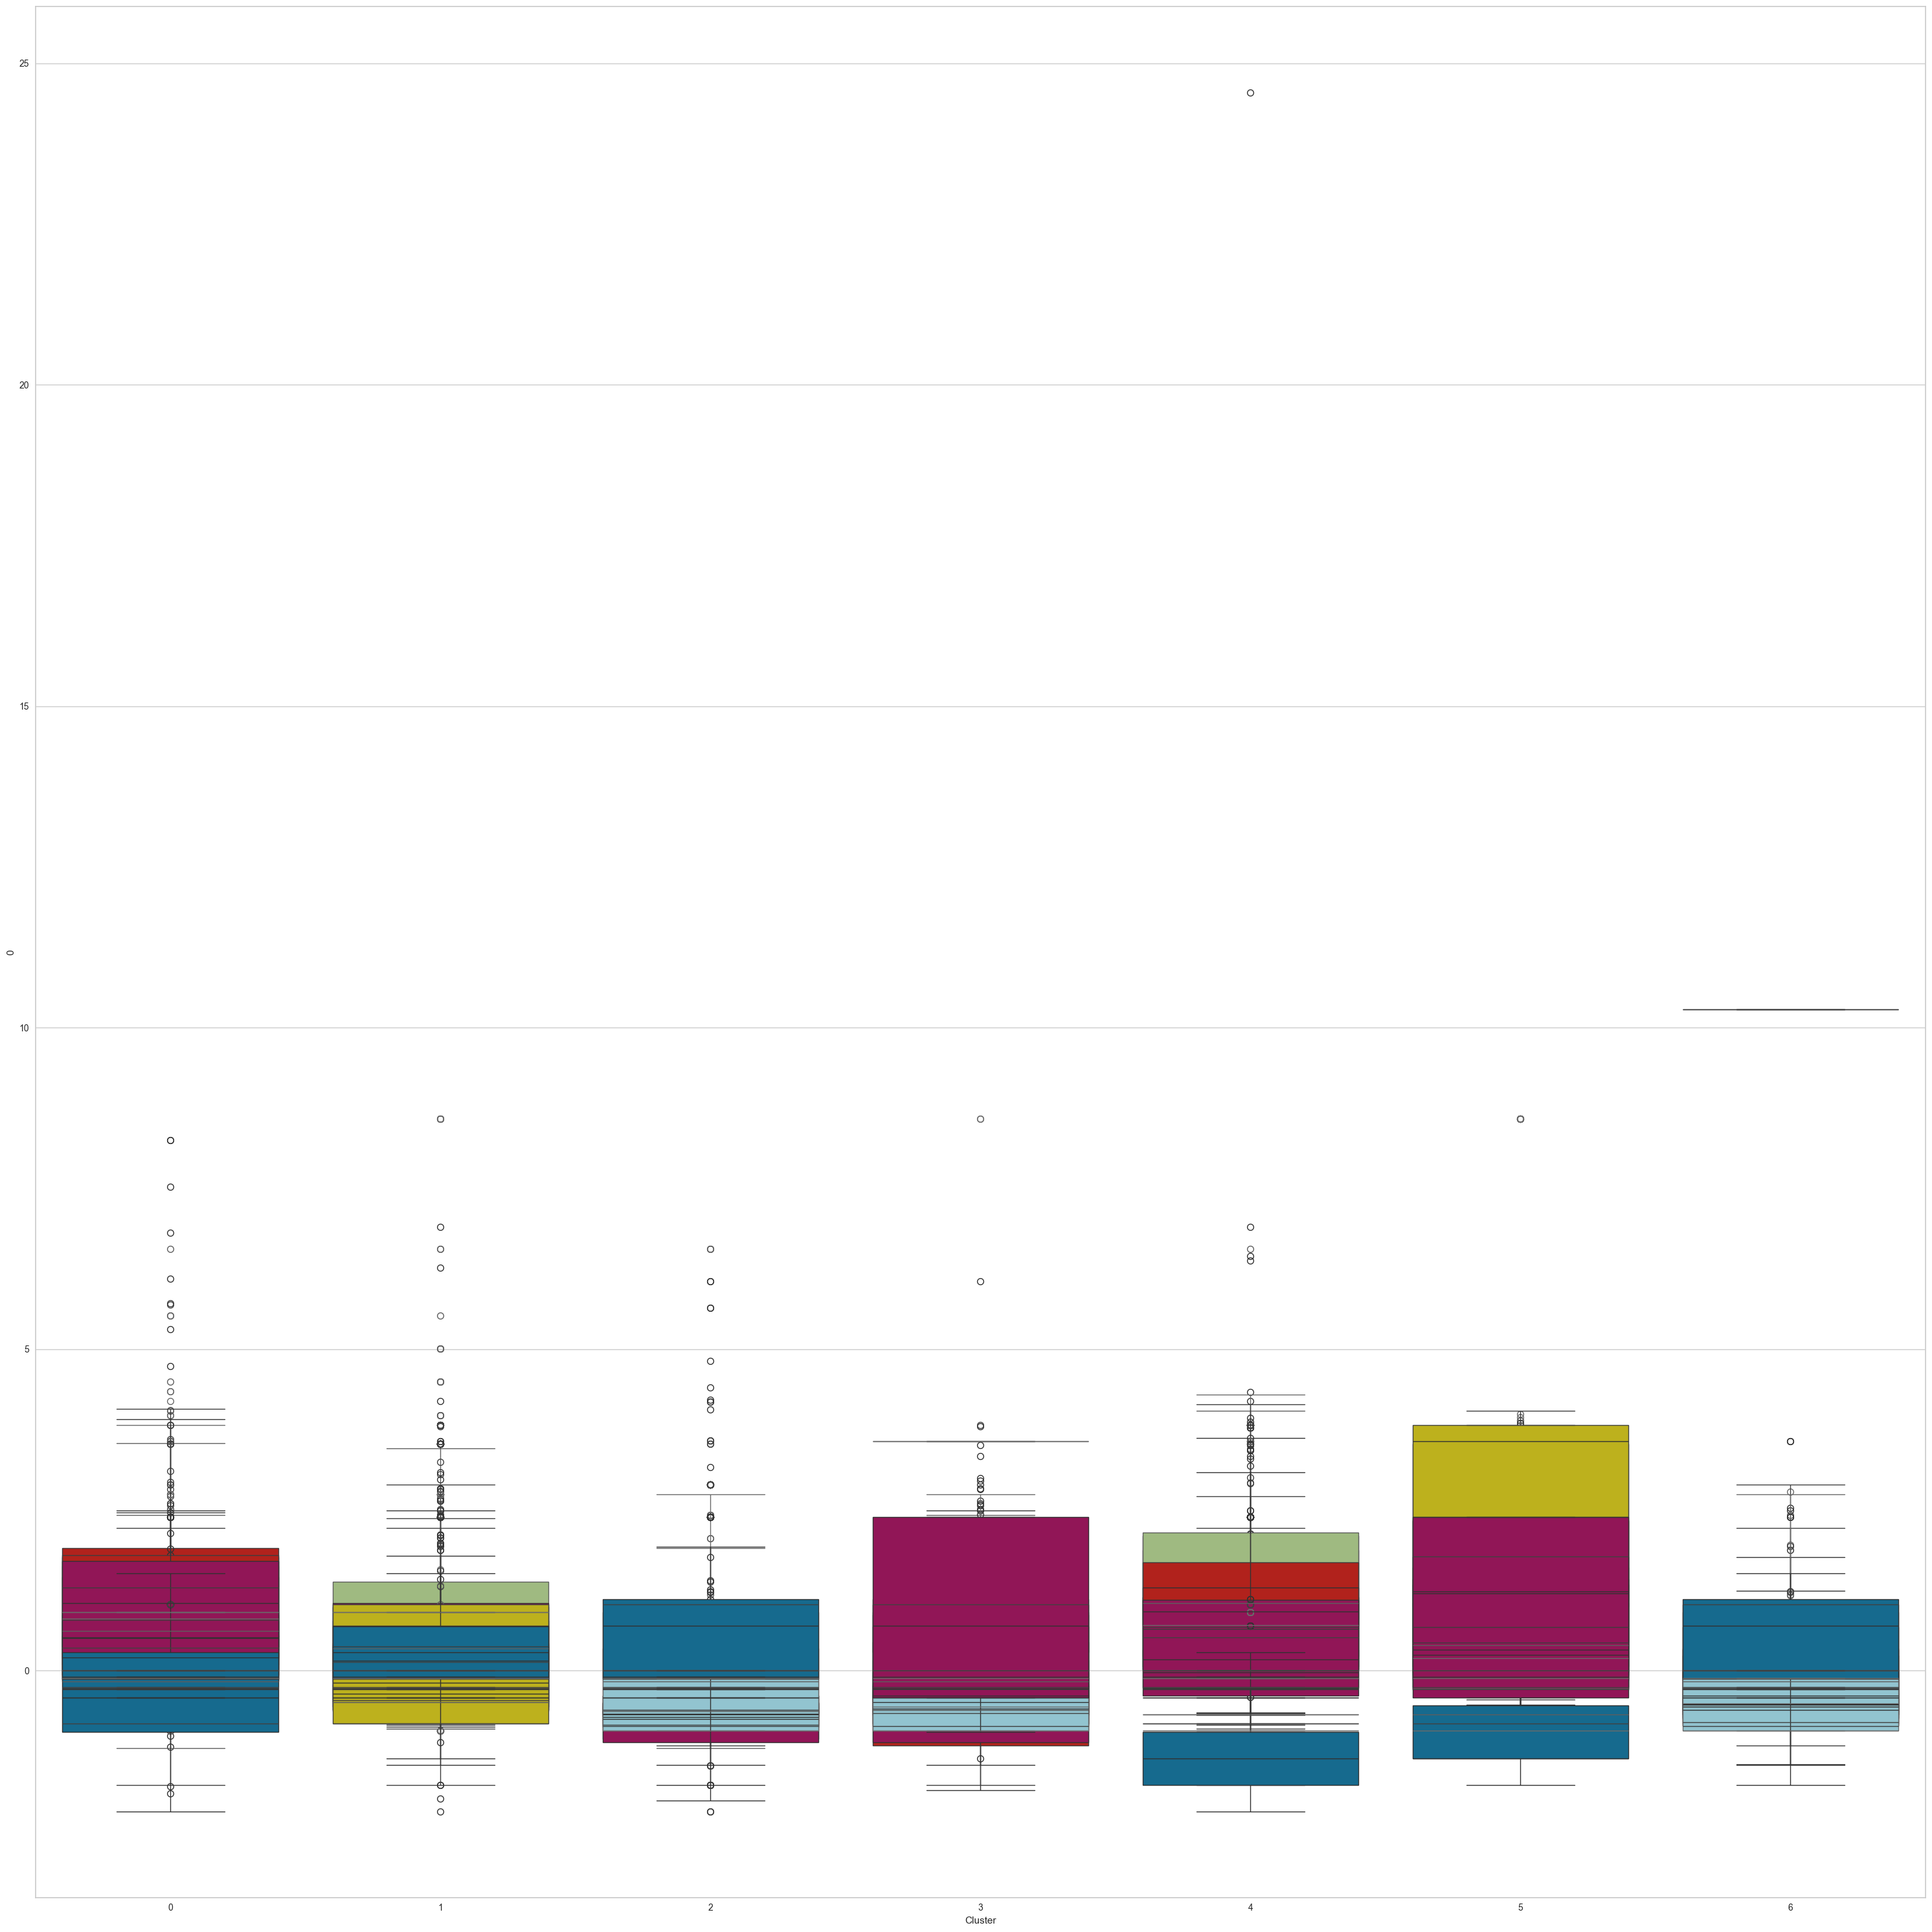

In [76]:
df['Cluster'] = kmeans.labels_


plt.figure(figsize=(30, 30))


for i, column in enumerate(df.columns.drop('Cluster')):
    sns.boxplot(data=df, x='Cluster', y=column)
    

plt.tight_layout()
plt.show()

##### **Observations:** Clusters 0,1,2 seem to have a significant number of outliers, but cluster 3 and 6 are quite uniform.

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

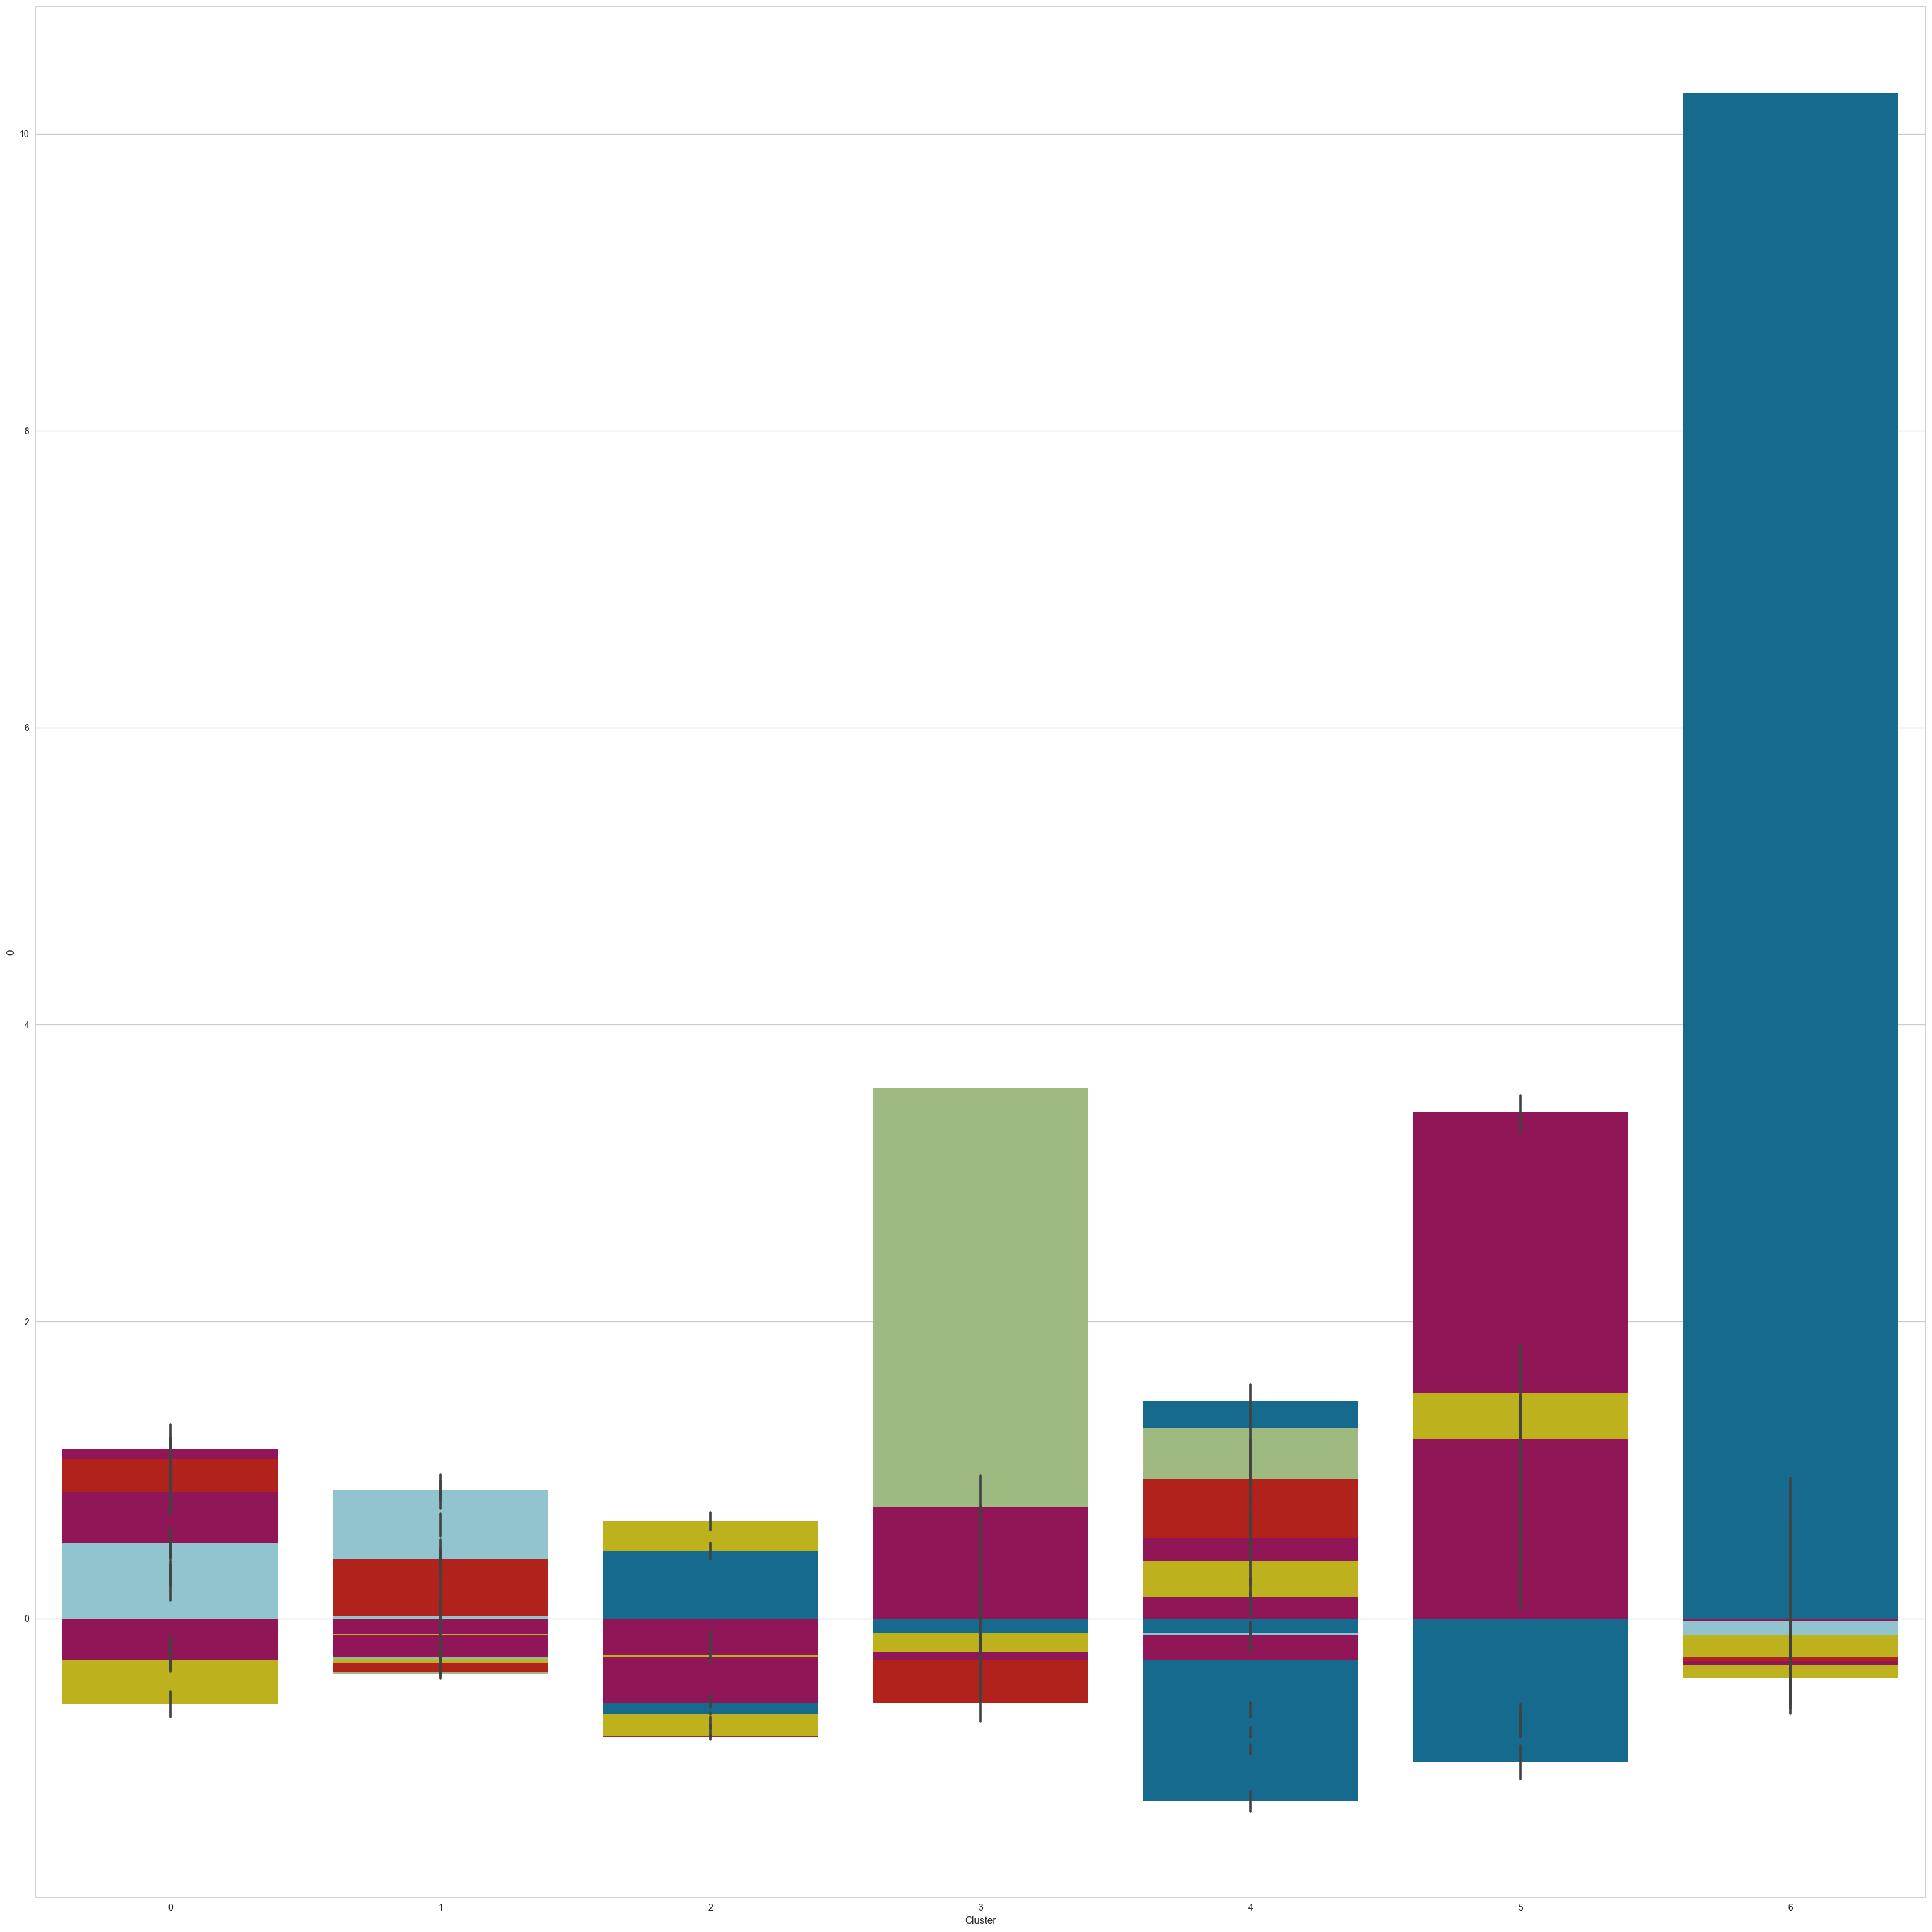

In [82]:
plt.figure(figsize=(30, 30)) 



for i, column in enumerate(df.columns.drop('Cluster')):
    sns.barplot(data=df, x='Cluster', y=column)
    

plt.tight_layout()
plt.show()

##### **Observations:**

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

## Unfortunately  based on the kmeans cluster insights, not much value can be provided. However if I were to analyze the data again, I would try to focus on 3 main areas, Income, Age, and Frequency of buying which could be derived from number of purchases (few vs many purchases). Based on the initial EDA, there is clear correlations between various aspects of the data and income, and this could be used to provide insights on how to market to low avg income vs high avg income customers. Also it would be useful to see if there is a certain age demographic that purchases more frequently as marketing towards them could also provide value.